#**Appliance Energy Forecasting**

###**Author:** Massab Naeem
###**GitHub:** https://github.com/massabnaeem05-create/Energy_forecast


##**Part 1: Data Prep, EDA & Stationarity**

1. Data prep & EDA (this section)
2. Forecasting problem definition
3. Benchmark models
4. SARIMAX
5. Covariates / feature engineering
6. Feature-based ML model (XGBoost etc.)
7. Foundation model (Chronos)
8. Evaluation
9. Discussion questions



### 1. Setup

In [ ]:
# !pip install pandas numpy matplotlib statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import os
os.makedirs("data", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)


## 1. Download & load the data

UCI Appliance Energy Prediction dataset (10-minute sampling).

In [ ]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
LOCAL_PATH = "data/energydata_complete.csv"

if not os.path.exists(LOCAL_PATH):
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
else:
    df_raw = pd.read_csv(LOCAL_PATH)

df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw = df_raw.set_index("date").sort_index()
print(df_raw.shape)
df_raw.head()


(19735, 28)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


### 1.1 Check for missing values and time gaps

In [ ]:
missing = df_raw.isna().sum()
print("Missing values per column (top 5):")
print(missing.sort_values(ascending=False).head())

full_range = pd.date_range(df_raw.index.min(), df_raw.index.max(), freq="10min")
gaps = full_range.difference(df_raw.index)
print(f"\nExpected {len(full_range)} timestamps at 10-min freq, got {len(df_raw)} rows -> {len(gaps)} missing timestamps.")


Missing values per column (top 5):
Appliances    0
lights        0
T1            0
RH_1          0
T2            0
dtype: int64

Expected 19735 timestamps at 10-min freq, got 19735 rows -> 0 missing timestamps.


### 1.2 Resample to hourly

`Appliances`/`lights` are energy readings (Wh per 10-min interval) → **sum** to get Wh per hour.

Sensor/weather columns are point-in-time readings → **average** over the hour.

In [ ]:
def resample_hourly(df, agg="mean"):
    energy_cols = ["Appliances", "lights"]
    sensor_cols = [c for c in df.columns if c not in energy_cols]

    hourly_energy = df[energy_cols].resample("1h").sum()
    hourly_sensors = df[sensor_cols].resample("1h").mean()

    hourly = pd.concat([hourly_energy, hourly_sensors], axis=1)
    hourly = hourly.dropna(how="all")
    return hourly

df = resample_hourly(df_raw)
print(df.shape)
df.to_csv("data/energy_hourly.csv")
df.head()


(3290, 28)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,330,210,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,1060,310,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,1040,150,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,750,210,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,620,140,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


## 2. Initial EDA plots

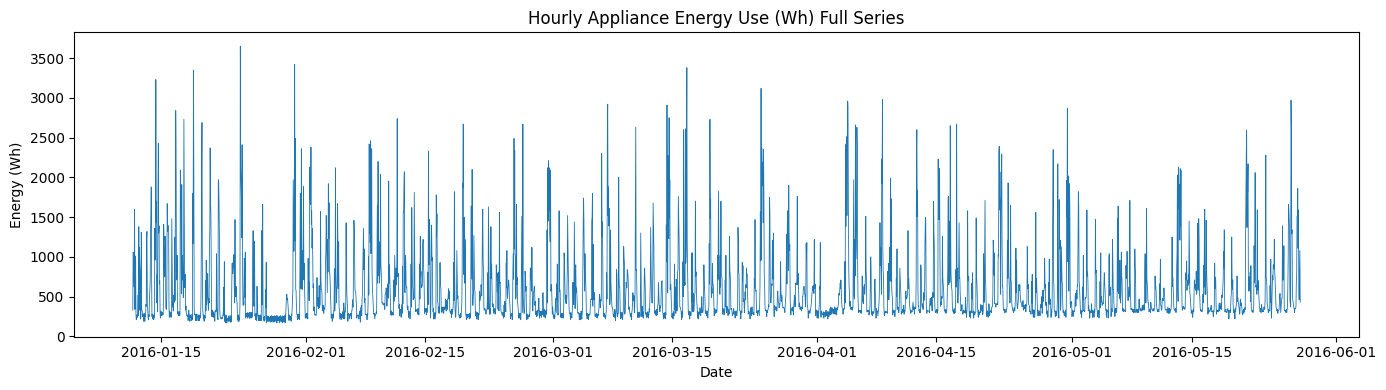

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["Appliances"], lw=0.6)
ax.set_title("Hourly Appliance Energy Use (Wh) Full Series")
ax.set_xlabel("Date"); ax.set_ylabel("Energy (Wh)")
fig.tight_layout()
fig.savefig("outputs/figures/01_full_series.png", dpi=120)
plt.show()


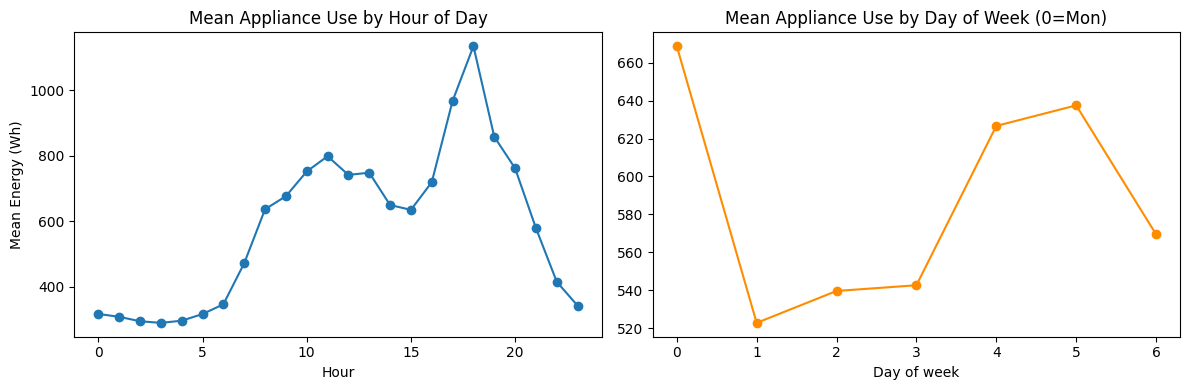

In [ ]:
hourly_avg = df.groupby(df.index.hour)["Appliances"].mean()
dow_avg = df.groupby(df.index.dayofweek)["Appliances"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hourly_avg.index, hourly_avg.values, marker="o")
axes[0].set_title("Mean Appliance Use by Hour of Day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Mean Energy (Wh)")

axes[1].plot(dow_avg.index, dow_avg.values, marker="o", color="darkorange")
axes[1].set_title("Mean Appliance Use by Day of Week (0=Mon)")
axes[1].set_xlabel("Day of week")
fig.tight_layout()
fig.savefig("outputs/figures/02_daily_weekly_pattern.png", dpi=120)
plt.show()


**Observations:** clear daily seasonality usage peaks ~17:00–19:00, trough overnight ~02:00–05:00. Mild weekly pattern (Monday highest, midweek lowest).

## 3. Seasonal decomposition

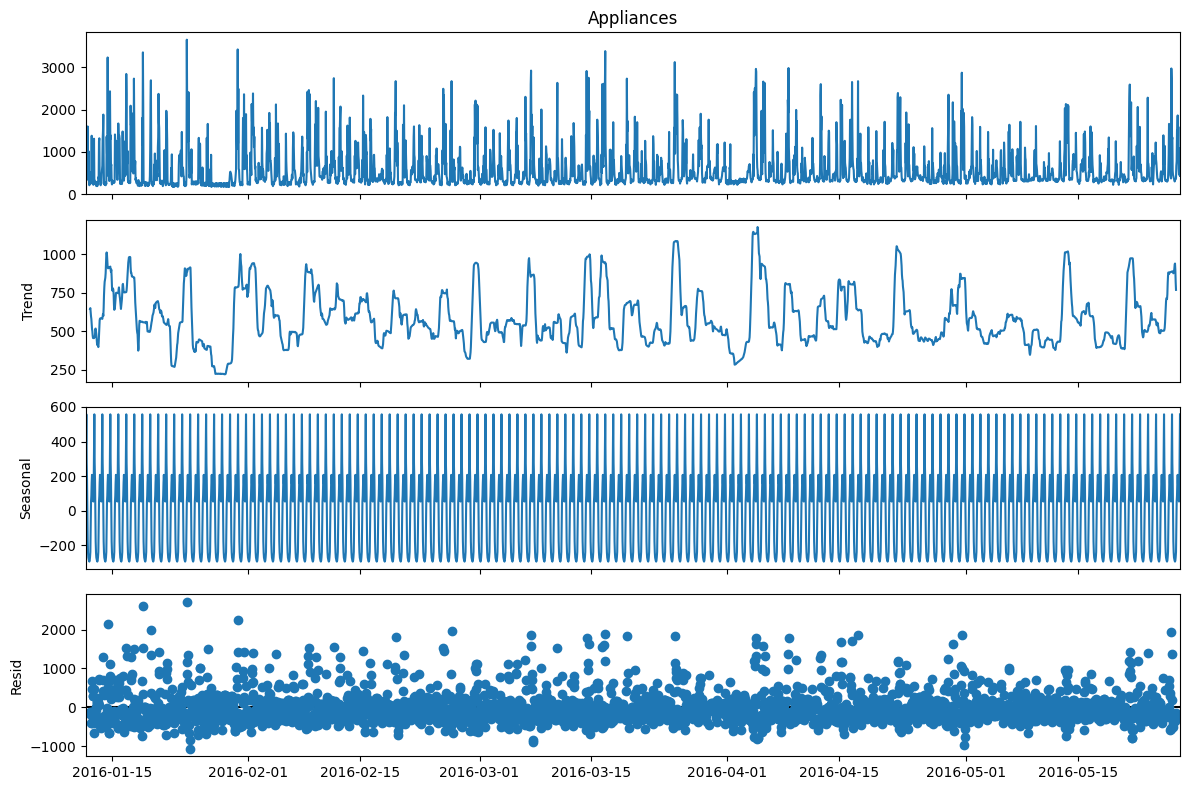

In [ ]:
result = seasonal_decompose(df["Appliances"], model="additive", period=24)
fig = result.plot()
fig.set_size_inches(12, 8)
fig.tight_layout()
fig.savefig("outputs/figures/03_decomposition_daily.png", dpi=120)
plt.show()


## 4. Stationarity analysis

Run **ADF** (H0: unit root / non-stationary) and **KPSS** (H0: stationary) on levels, first differences, and 24h seasonal differences, plus ACF/PACF at each stage.

In [ ]:
def plot_acf_pacf(series, lags=72, name="levels"):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(series.dropna(), lags=lags, ax=axes[0]); axes[0].set_title(f"ACF: {name}")
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm"); axes[1].set_title(f"PACF: {name}")
    fig.tight_layout()
    fig.savefig(f"outputs/figures/04_acf_pacf_{name}.png", dpi=120)
    plt.show()

def run_adf(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF: {label}: stat={result[0]:.4f}, p={result[1]:.4f}",
          "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY")
    return result

def run_kpss(series, label):
    result = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"KPSS: {label}: stat={result[0]:.4f}, p={result[1]:.4f}",
          "NON-STATIONARY" if result[1] < 0.05 else "STATIONARY")
    return result


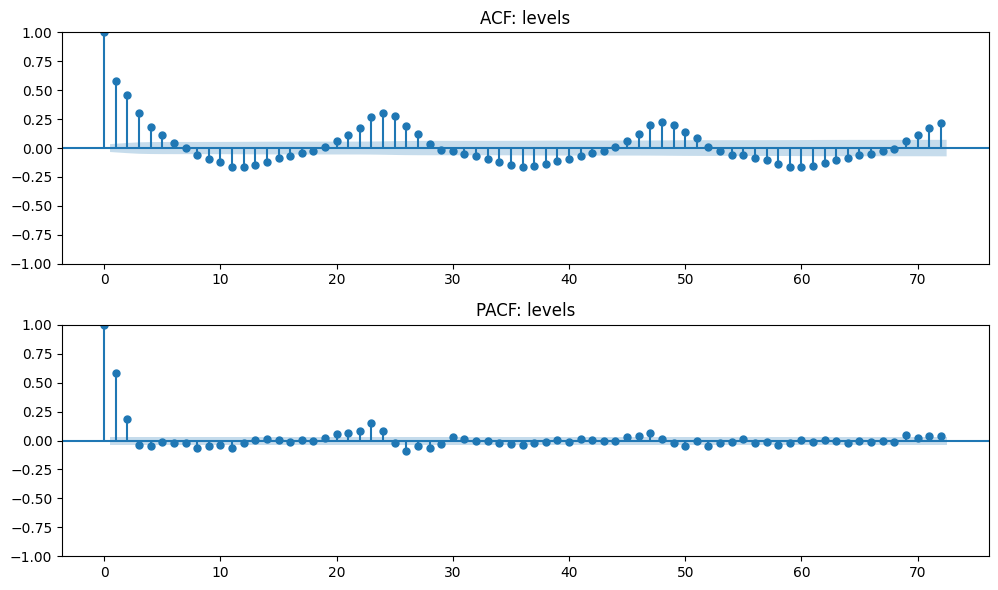

ADF: levels: stat=-9.1269, p=0.0000 STATIONARY
KPSS: levels: stat=0.0416, p=0.1000 STATIONARY


/tmp/ipykernel_1907/149315218.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


(np.float64(0.041568083560503975),
 np.float64(0.1),
 25,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [ ]:
plot_acf_pacf(df["Appliances"], lags=72, name="levels")
run_adf(df["Appliances"], "levels")
run_kpss(df["Appliances"], "levels")


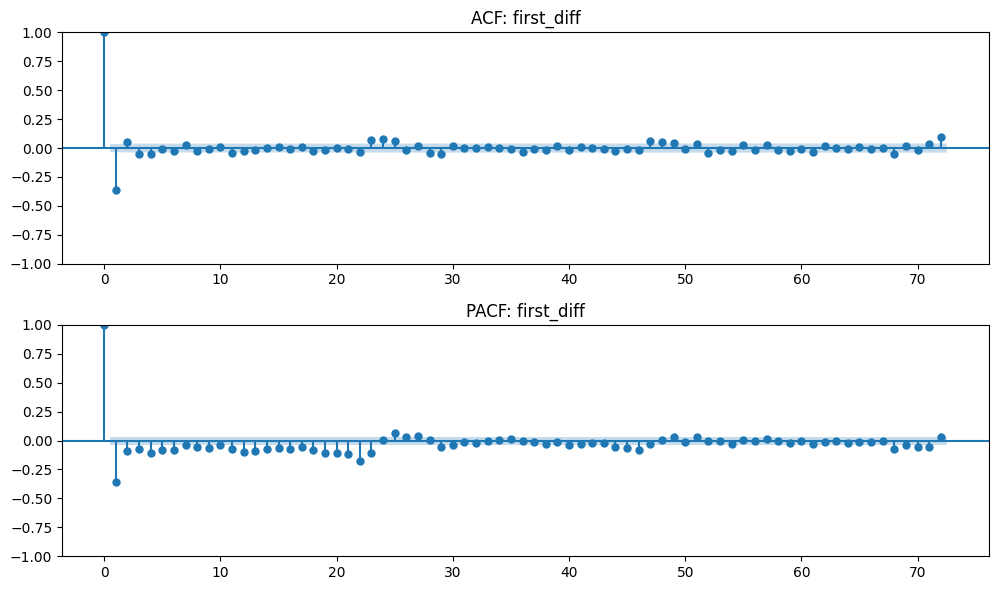

ADF: 1st diff: stat=-16.9070, p=0.0000 STATIONARY
KPSS: 1st diff: stat=0.0177, p=0.1000 STATIONARY


/tmp/ipykernel_1907/149315218.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


(np.float64(0.017655940901555218),
 np.float64(0.1),
 110,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [ ]:
diff1 = df["Appliances"].diff().dropna()
plot_acf_pacf(diff1, lags=72, name="first_diff")
run_adf(diff1, "1st diff")
run_kpss(diff1, "1st diff")


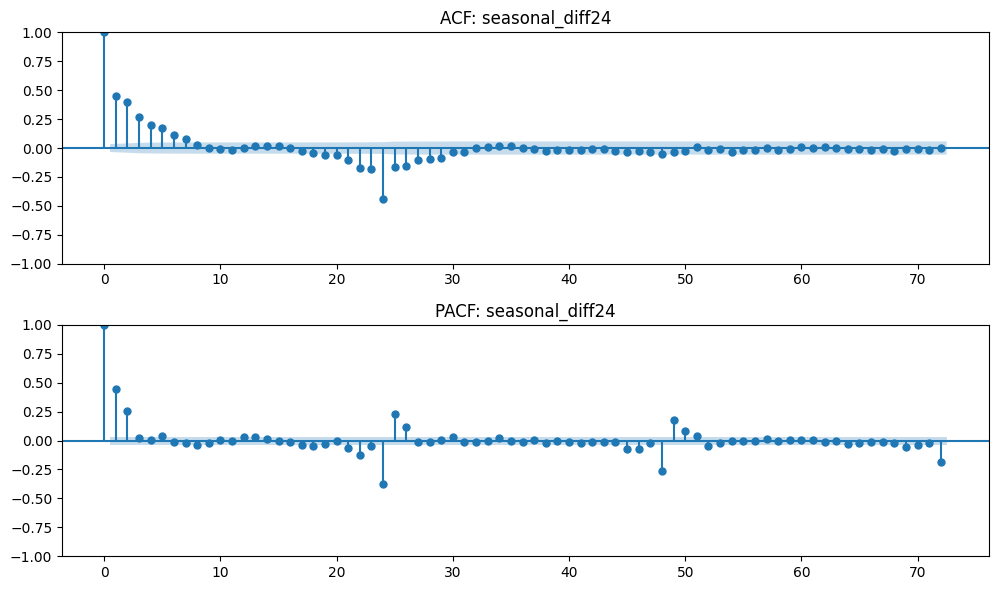

ADF: seasonal diff (24h): stat=-13.6460, p=0.0000 STATIONARY
KPSS: seasonal diff (24h): stat=0.0065, p=0.1000 STATIONARY


/tmp/ipykernel_1907/149315218.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


(np.float64(0.006508491292703798),
 np.float64(0.1),
 27,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [ ]:
sdiff = df["Appliances"].diff(24).dropna()
plot_acf_pacf(sdiff, lags=72, name="seasonal_diff24")
run_adf(sdiff, "seasonal diff (24h)")
run_kpss(sdiff, "seasonal diff (24h)")


### Part 1: Summary of findings

- No missing values, no time gaps in the raw 10-min data.
- Clean resample to hourly (sum energy columns, mean sensor columns).
- Strong **daily seasonality** (period 24h): peak ~17:00–19:00, trough ~02:00–05:00.
- Mild **weekly seasonality**: Monday highest, midweek lowest.
- ADF and KPSS **agree the raw level series is already stationary** (no unit root, mean-reverting), but the ACF shows slow oscillating decay with strong repeated spikes at lags 24/48/72 the classic signature of **seasonal structure**, which motivates using seasonal differencing / seasonal orders (s=24) in SARIMAX in Part 4, even though a plain unit-root test doesn't require it.
- First-difference and seasonal-difference (24h) series are also stationary.

##**Part 2: Defining the Forecasting Problem**

Before modelling, fix the problem specification so every model (benchmarks, SARIMAX, ML, foundation model) is evaluated on exactly the same footing.


## 2.1 Target variable

**Target: `Appliances`** hourly appliance energy consumption (Wh), as prepared in Part 1.

We forecast `Appliances` only (not `Appliances + lights`), since `lights` is a separate, much smaller and more irregular load (mostly on/off events) and the assignment brief refers throughout to "appliance energy demand" as the object of interest.


## 2.2 Forecast horizon

**Horizon: 24 hours ahead** (one full day, hourly steps), as specified in Parts 3, 4, 6 and 7 of the assignment.

This is a fixed-origin, multi-step-ahead forecast: given all data up to some cutoff time \(t\), forecast \(t+1, t+2, \dots, t+24\).


## 2.3 Train / test split

We use a **chronological (no shuffling) split**, which is mandatory for time series a random split would leak future information into training.

- **Feature-based ML model (Part 6):** the assignment specifies **the last 14 days** as the test period.
- To keep every model comparable, we use the **same last-14-days window as the common test period** for all models (benchmarks, SARIMAX, ML model, foundation model).
- Everything before the last 14 days is available for training / fitting.
- Within evaluation, we score each model's ability to forecast the **first 24 hours of the test window** (as required by Parts 3, 4, 6, 7), and we also report a **rolling evaluation across the full 14-day test period** (repeating the 24h forecast at multiple origins) for a more robust comparison in Part 8.

This gives us:
- A **single held-out block** models never see during fitting/training (avoiding leakage).
- A way to satisfy the "24-hour forecast" requirement per part **and** get a statistically meaningful comparison across models (14 independent/overlapping 24h windows instead of just one).


In [ ]:
TEST_DAYS = 14
HORIZON = 24  # hours

test_start = df.index.max() - pd.Timedelta(days=TEST_DAYS) + pd.Timedelta(hours=1)
train = df.loc[:test_start - pd.Timedelta(hours=1)]
test = df.loc[test_start:]

print(f"Full range:  {df.index.min()}  ->  {df.index.max()}  ({len(df)} hours)")
print(f"Train range: {train.index.min()}  ->  {train.index.max()}  ({len(train)} hours)")
print(f"Test range:  {test.index.min()}  ->  {test.index.max()}  ({len(test)} hours)")
assert len(test) == TEST_DAYS * 24, "Test window should be exactly 14*24 hours"


Full range:  2016-01-11 17:00:00  ->  2016-05-27 18:00:00  (3290 hours)
Train range: 2016-01-11 17:00:00  ->  2016-05-13 18:00:00  (2954 hours)
Test range:  2016-05-13 19:00:00  ->  2016-05-27 18:00:00  (336 hours)


## 2.4 Evaluation metrics

We report multiple complementary metrics, since RMSE alone can be dominated by the sharp usage spikes visible in Part 1:

| Metric | Why we use it |
|---|---|
| **RMSE** (root mean squared error) | Explicitly requested in the assignment; penalises large errors (spikes) heavily |
| **MAE** (mean absolute error) | More robust to outliers/spikes than RMSE; easier to interpret in Wh |
| **MAPE** (mean absolute percentage error) | Scale-free, but unstable when actuals are near zero we report it with that caveat, since `Appliances` has a hard floor around 10–60 Wh, not literal zero |
| **sMAPE** (symmetric MAPE) | More stable than MAPE when values are small but non-zero |

All metrics are computed **per 24-hour forecast window**, then averaged across the rolling test windows (Part 8) to get a single robust score per model, alongside the single first-window score required by Parts 3/4/6/7.


In [ ]:
def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)

def smape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.clip((np.abs(y_true) + np.abs(y_pred)) / 2, eps, None)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100)

def evaluate(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }

# Sanity check: perfect forecast -> all metrics 0
print(evaluate(test["Appliances"].values[:24], test["Appliances"].values[:24]))


{'RMSE': 0.0, 'MAE': 0.0, 'MAPE': 0.0, 'sMAPE': 0.0}


### Part 2: Summary

| Item | Decision |
|---|---|
| Target variable | `Appliances` (hourly Wh) |
| Forecast horizon | 24 hours ahead |
| Train period | All data except last 14 days |
| Test period | Last 14 days (336 hours), common to all models |
| Primary reported metrics | RMSE, MAE, MAPE, sMAPE |
| Evaluation protocol | Score on first 24h of test window (per assignment parts) **and** rolling 24h windows across the full test period (for Part 8 robustness) |




##**Part 3: Benchmark Models**

Fit five simple benchmark forecasters, all producing a 24-hour-ahead forecast from the training data (or from data available up to the forecast origin, for the rolling evaluation). These give us a floor that any more sophisticated model (SARIMAX, ML, foundation model) must clearly beat to be worth its added complexity.

- **Mean**: forecast = mean of all training data
- **Naive**: forecast = last observed value, repeated for all 24 steps
- **Daily seasonal naive**: forecast for hour *h* on the target day = value at the same hour on the previous day (lag 24)
- **Weekly seasonal naive**: forecast for hour *h* = value at the same hour, same day-of-week, previous week (lag 168)
- **Drift**: naive plus a linear trend extrapolated from the average change over the training period


In [ ]:
TARGET = "Appliances"
HORIZON = 24
TEST_DAYS = 14

test_start = df.index.max() - pd.Timedelta(days=TEST_DAYS) + pd.Timedelta(hours=1)
train = df.loc[:test_start - pd.Timedelta(hours=1)]
test = df.loc[test_start:]

print(f"Train: {train.index.min()} -> {train.index.max()} ({len(train)} hrs)")
print(f"Test:  {test.index.min()} -> {test.index.max()} ({len(test)} hrs)")

Train: 2016-01-11 17:00:00 -> 2016-05-13 18:00:00 (2954 hrs)
Test:  2016-05-13 19:00:00 -> 2016-05-27 18:00:00 (336 hrs)


## 3.1 Benchmark forecast functions

Each function takes the *history available up to the forecast origin* and returns a 24-length array.

In [ ]:
def forecast_mean(history: pd.Series, horizon: int = HORIZON) -> np.ndarray:
    return np.full(horizon, history.mean())

def forecast_naive(history: pd.Series, horizon: int = HORIZON) -> np.ndarray:
    return np.full(horizon, history.iloc[-1])

def forecast_seasonal_naive(history: pd.Series, season: int, horizon: int = HORIZON) -> np.ndarray:
    """Repeat the last full season (season=24 for daily, 168 for weekly)."""
    last_season = history.iloc[-season:].values
    reps = int(np.ceil(horizon / season))
    return np.tile(last_season, reps)[:horizon]

def forecast_drift(history: pd.Series, horizon: int = HORIZON) -> np.ndarray:
    """Naive + linear extrapolation of the average step-to-step change."""
    y0 = history.iloc[-1]
    n = len(history)
    avg_change = (history.iloc[-1] - history.iloc[0]) / (n - 1)
    steps = np.arange(1, horizon + 1)
    return y0 + avg_change * steps

BENCHMARKS = {
    "Mean": lambda h: forecast_mean(h),
    "Naive": lambda h: forecast_naive(h),
    "Daily Seasonal Naive": lambda h: forecast_seasonal_naive(h, season=24),
    "Weekly Seasonal Naive": lambda h: forecast_seasonal_naive(h, season=168),
    "Drift": lambda h: forecast_drift(h),
}


## 3.2 Forecast the first 24 hours of the test period

This matches the assignment's requirement ("Use a 24 hour forecast horizon") using the train/test split from Part 2.


In [ ]:
y_true = test[TARGET].iloc[:HORIZON].values
forecast_index = test.index[:HORIZON]

benchmark_forecasts = {}
for name, fn in BENCHMARKS.items():
    benchmark_forecasts[name] = fn(train[TARGET])

forecasts_df = pd.DataFrame(benchmark_forecasts, index=forecast_index)
forecasts_df["Actual"] = y_true
forecasts_df


,Mean,Naive,Daily Seasonal Naive,Weekly Seasonal Naive,Drift,Actual
date,,,,,,
2016-05-13 19:00:00,584.769804,2090,740,760,2090.596004,1250
2016-05-13 20:00:00,584.769804,2090,600,700,2091.192008,720
2016-05-13 21:00:00,584.769804,2090,430,430,2091.788012,380
2016-05-13 22:00:00,584.769804,2090,360,320,2092.384016,330
2016-05-13 23:00:00,584.769804,2090,340,350,2092.980020,370
2016-05-14 00:00:00,584.769804,2090,330,310,2093.576024,350
2016-05-14 01:00:00,584.769804,2090,320,340,2094.172028,380
2016-05-14 02:00:00,584.769804,2090,350,320,2094.768033,360
2016-05-14 03:00:00,584.769804,2090,350,330,2095.364037,360


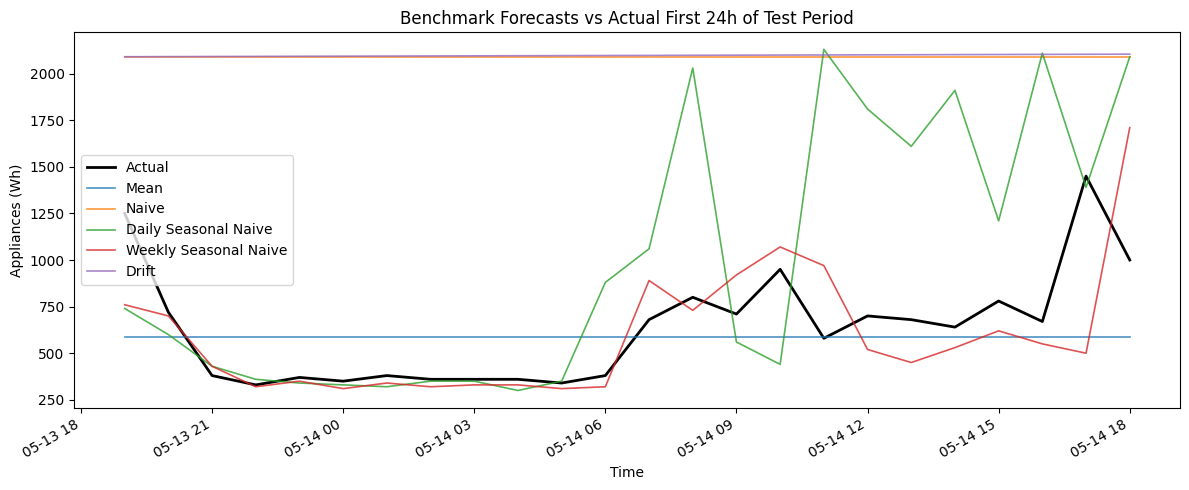

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(forecasts_df.index, forecasts_df["Actual"], label="Actual", color="black", lw=2)
for name in BENCHMARKS:
    ax.plot(forecasts_df.index, forecasts_df[name], label=name, lw=1.2, alpha=0.8)
ax.set_title("Benchmark Forecasts vs Actual First 24h of Test Period")
ax.set_xlabel("Time"); ax.set_ylabel("Appliances (Wh)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("outputs/figures/05_benchmark_forecasts_24h.png", dpi=120)
plt.show()


## 3.3 Evaluate on the first 24h window

In [ ]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def mape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)

def smape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.clip((np.abs(y_true) + np.abs(y_pred)) / 2, eps, None)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100)

def evaluate(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred),
            "MAPE": mape(y_true, y_pred), "sMAPE": smape(y_true, y_pred)}

results_24h = {name: evaluate(y_true, forecasts_df[name].values) for name in BENCHMARKS}
results_24h_df = pd.DataFrame(results_24h).T.sort_values("RMSE")
results_24h_df


,RMSE,MAE,MAPE,sMAPE
Weekly Seasonal Naive,292.845238,180.000000,22.444402,23.190378
Mean,300.037813,236.269183,40.464169,37.614696
Daily Seasonal Naive,708.260781,481.666667,70.613314,44.204105
Naive,1485.608742,1455.833333,298.667465,110.214271
Drift,1492.548750,1463.283384,299.909206,110.469634


## 3.4 Rolling evaluation across the full 14-day test period

A single 24h window can be misleading (e.g. an unusually quiet or busy day). We repeat the 24h forecast at the start of every day in the test period (14 non-overlapping windows), re-fitting only where the forecast function needs updated history (all benchmarks here just re-read history no parameters to refit), and average the metrics. This is the score we treat as primary in Part 8's model comparison.


In [ ]:
def rolling_evaluate(forecast_fn, full_series: pd.Series, test_index: pd.DatetimeIndex,
                      horizon: int = HORIZON):
    """Roll a 24h forecast through the test period, one window per day."""
    scores = []
    n_windows = len(test_index) // horizon
    for w in range(n_windows):
        origin_time = test_index[w * horizon] - pd.Timedelta(hours=1)
        history = full_series.loc[:origin_time]
        y_true_w = full_series.loc[test_index[w * horizon: w * horizon + horizon]].values
        y_pred_w = forecast_fn(history)
        scores.append(evaluate(y_true_w, y_pred_w))
    return pd.DataFrame(scores)

rolling_results = {}
for name, fn in BENCHMARKS.items():
    scores_df = rolling_evaluate(fn, df[TARGET], test.index)
    rolling_results[name] = scores_df.mean()

rolling_results_df = pd.DataFrame(rolling_results).T.sort_values("RMSE")
rolling_results_df.to_csv("outputs/benchmark_rolling_results.csv")
rolling_results_df


,RMSE,MAE,MAPE,sMAPE
Mean,391.224401,296.071229,53.572613,46.003891
Weekly Seasonal Naive,404.944286,254.583333,37.138390,32.504015
Daily Seasonal Naive,455.757454,288.571429,43.773339,35.548784
Naive,584.713034,512.023810,113.357094,65.419410
Drift,586.077500,513.574778,113.761177,65.530006


### Part 3: Summary

- Five benchmarks implemented: Mean, Naive, Daily Seasonal Naive, Weekly Seasonal Naive, Drift.
- Evaluated both on the single first-24h test window (matches the assignment's literal instruction) and via a rolling 14-window evaluation across the full test period (more robust, used as the primary score for later model comparison in Part 8).

**Rolling 14-window results (mean over 14 days):**

| Model | RMSE | MAE | MAPE | sMAPE |
|---|---|---|---|---|
| Mean | **391.2** (best RMSE) | 296.1 | 53.6% | 46.0% |
| Weekly Seasonal Naive | 404.9 | **254.6** (best MAE) | **37.1%** (best MAPE) | **32.5%** (best sMAPE) |
| Daily Seasonal Naive | 455.8 | 288.6 | 43.8% | 35.5% |
| Naive | 584.7 | 512.0 | 113.4% | 65.4% |
| Drift | 586.1 | 513.6 | 113.8% | 65.5% |



##**Part 4: SARIMAX Model**

Part 1 established strong daily (24h) seasonality with peaks/troughs oscillating in the ACF at lags 24, 48, 72. This motivates a **SARIMA** model with a seasonal period of 24. We don't yet add exogenous variables here (that comes in Part 5) this section fits SARIMA on the target series alone.

**Note on seasonal order:** the assignment asks us to loop over non-seasonal `(p,d,q)` combinations via AIC; it does not ask for a seasonal grid search. We therefore **fix the seasonal order using the diagnostics from Part 1**: the 24h-seasonal-differenced series was confirmed stationary (ADF/KPSS), so we set seasonal `D=1`, `s=24`, and use one seasonal AR and one seasonal MA term (`P=1, Q=1`) as a standard, well-justified starting point i.e. seasonal order `(1,1,1,24)`.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import itertools
from scipy.stats import norm

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

TARGET = "Appliances"
HORIZON = 24
TEST_DAYS = 14

test_start = df.index.max() - pd.Timedelta(days=TEST_DAYS) + pd.Timedelta(hours=1)
train = df.loc[:test_start - pd.Timedelta(hours=1)]
test = df.loc[test_start:]

SEASONAL_ORDER = (1, 1, 1, 24)

## 4.1 AIC grid search over (p, d, q)

We loop over **all** combinations of `p ∈ [0,6]`, `d ∈ [0,2]`, `q ∈ [0,6]` 147 combinations as required.



In [ ]:
SEARCH_WINDOW = 720  # hours (30 days), used only for order selection speed
P_RANGE, D_RANGE, Q_RANGE = range(0, 7), range(0, 3), range(0, 7)

def grid_search_orders(train_series, search_window=SEARCH_WINDOW,
                        seasonal_order=SEASONAL_ORDER, maxiter=25):
    subset = train_series.iloc[-search_window:]
    combos = list(itertools.product(P_RANGE, D_RANGE, Q_RANGE))
    records = []
    for i, (p, d, q) in enumerate(combos):
        t0 = time.time()
        try:
            model = SARIMAX(subset, order=(p, d, q), seasonal_order=seasonal_order,
                             enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False, maxiter=maxiter, method="lbfgs")
            aic = res.aic
        except Exception:
            aic = np.inf
        records.append({"p": p, "d": d, "q": q, "AIC": aic,
                         "fit_seconds": round(time.time() - t0, 2)})
        if (i + 1) % 25 == 0:
            print(f"  ...{i+1}/{len(combos)} combinations tried")
    return pd.DataFrame(records).sort_values("AIC").reset_index(drop=True)

print(f"Grid search over {len(list(P_RANGE))*len(list(D_RANGE))*len(list(Q_RANGE))} combinations "
      f"on last {SEARCH_WINDOW}h of training data (this takes ~15-20 minutes)...")
grid_results = grid_search_orders(train[TARGET])
grid_results.to_csv("outputs/sarimax_grid_search.csv", index=False)
grid_results.head(10)


Grid search over 147 combinations on last 720h of training data (this takes ~15-20 minutes)...
  ...25/147 combinations tried
  ...50/147 combinations tried
  ...75/147 combinations tried
  ...100/147 combinations tried
  ...125/147 combinations tried


,p,d,q,AIC,fit_seconds
0,1,0,6,9621.568086,11.27
1,0,0,6,9625.213712,10.22
2,6,0,0,9629.535777,8.49
3,0,1,5,9630.859454,9.11
4,5,0,0,9640.973671,7.18
5,0,0,5,9641.751682,7.57
6,1,0,4,9641.829697,7.67
7,0,1,6,9642.009518,10.88
8,0,1,4,9645.244295,7.02
9,6,1,0,9653.957907,10.30


In [ ]:
best = grid_results.iloc[0]
BEST_ORDER = (int(best.p), int(best.d), int(best.q))
print(f"Best order by AIC: SARIMA{BEST_ORDER} x {SEASONAL_ORDER}, AIC={best.AIC:.1f} (on search subset)")


Best order by AIC: SARIMA(1, 0, 6) x (1, 1, 1, 24), AIC=9621.6 (on search subset)


## 4.2 Refit on the full training set

We now refit this order on the entire training period (2,954 hours) to get our final model the search subset was only used to identify the order cheaply.

In [ ]:
model = SARIMAX(train[TARGET], order=BEST_ORDER, seasonal_order=SEASONAL_ORDER,
                 enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False, maxiter=150, method="lbfgs")
print("Converged:", res.mle_retvals.get("converged"))
print(res.summary())


Converged: True
                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2954
Model:             SARIMAX(1, 0, 6)x(1, 1, [1], 24)   Log Likelihood              -21258.324
Date:                              Fri, 07 Aug 2026   AIC                          42536.648
Time:                                      06:26:22   BIC                          42596.369
Sample:                                  01-11-2016   HQIC                         42558.167
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6496      0.127      5.121      0.000       0.401       0.898
ma.

## 4.3 Residual diagnostics

We check whether the residuals behave like white noise (no remaining structure the model failed to capture):
- **ACF of residuals**: should show no significant spikes at any lag, especially lag 24 (would indicate leftover daily seasonality)
- **Ljung-Box test**: formal test for residual autocorrelation up to a given lag
- **Distribution / Q-Q plot**: checks whether residuals are approximately normal (matters for how much we trust the Gaussian confidence intervals)


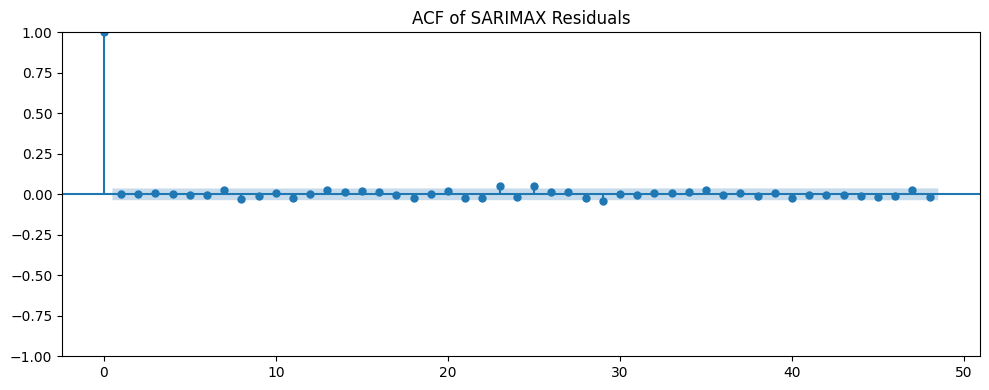

Ljung-Box test (H0: no autocorrelation up to lag):
      lb_stat  lb_pvalue
24  25.437946   0.382284
48  52.078614   0.318223


In [ ]:
resid = res.resid

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid.dropna(), lags=48, ax=ax)
ax.set_title("ACF of SARIMAX Residuals")
fig.tight_layout()
fig.savefig("outputs/figures/06_sarimax_residual_acf.png", dpi=120)
plt.show()

lb = acorr_ljungbox(resid, lags=[24, 48], return_df=True)
print("Ljung-Box test (H0: no autocorrelation up to lag):")
print(lb)


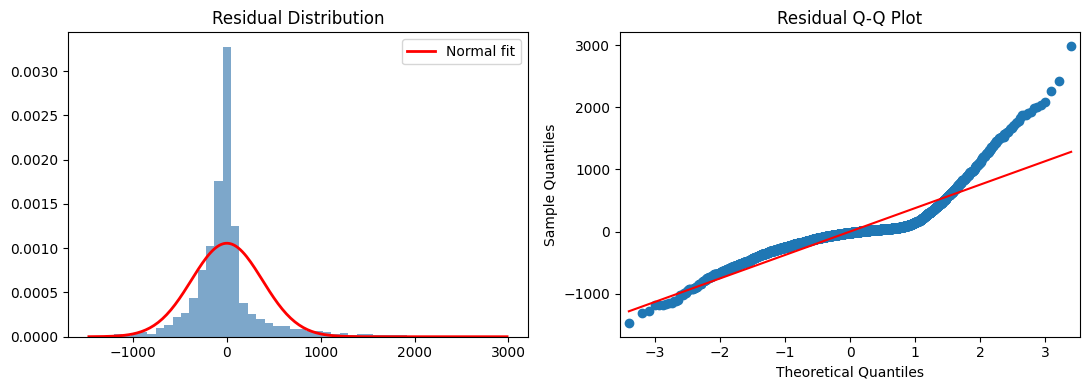

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(resid, bins=50, density=True, alpha=0.7, color="steelblue")
mu, sigma = resid.mean(), resid.std()
x = np.linspace(resid.min(), resid.max(), 200)
axes[0].plot(x, norm.pdf(x, mu, sigma), color="red", lw=2, label="Normal fit")
axes[0].set_title("Residual Distribution")
axes[0].legend()

qqplot(resid.dropna(), line="s", ax=axes[1])
axes[1].set_title("Residual Q-Q Plot")

fig.tight_layout()
fig.savefig("outputs/figures/07_sarimax_residual_dist.png", dpi=120)
plt.show()


**Diagnosis:**
- The residual ACF shows **no significant spikes at any lag** (including 24/48) confirmed by the Ljung-Box test, which **fails to reject the null of no autocorrelation** (p ≈ 0.38 at lag 24, p ≈ 0.32 at lag 48). The model has captured essentially all of the linear autocorrelation and daily seasonal structure.
- However, the residual distribution is **not normal**: it is sharply peaked with heavy tails (high kurtosis, positive skew visible in both the histogram and the Q-Q plot's curvature away from the reference line). This is expected: appliance usage spikes are occasional and large, and a linear Gaussian model cannot fully anticipate their exact timing/size. This means the model's **point forecasts** are reliable (uncorrelated residuals), but its **Gaussian confidence intervals understate the true probability of large deviations (spikes)** an important limitation to note in the report.


## 4.4 Forecast the next 24 hours with confidence intervals

First-24h test metrics: {'RMSE': np.float64(159.59649583344824), 'MAE': np.float64(112.72218088125457), 'MAPE': np.float64(19.45185164889137), 'sMAPE': np.float64(17.173358158330988)}


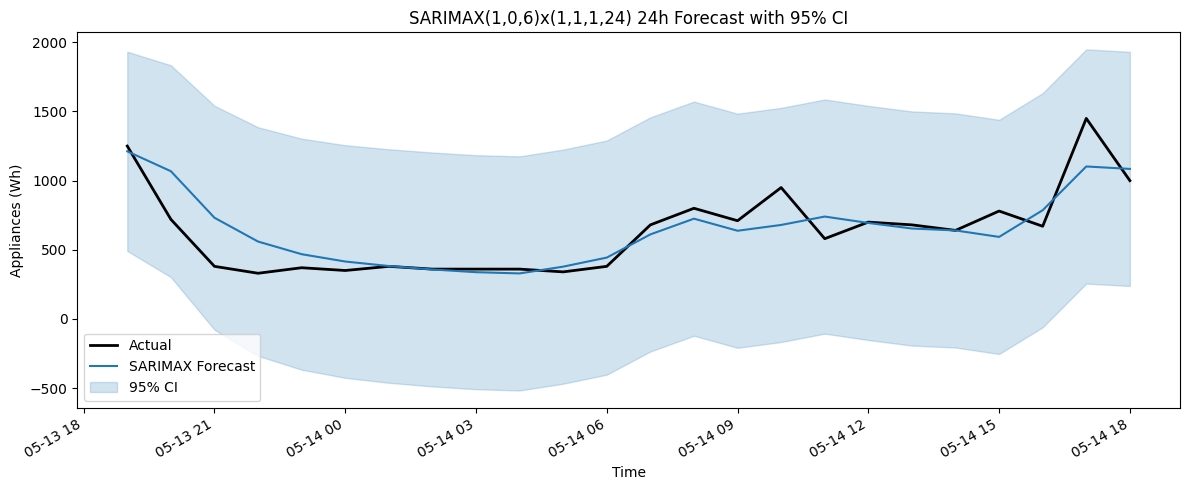

In [ ]:
def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100
    denom = np.clip((np.abs(y_true) + np.abs(y_pred)) / 2, 1e-6, None)
    smape = np.mean(np.abs(y_true - y_pred) / denom) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "sMAPE": smape}

fc = res.get_forecast(steps=HORIZON)
forecast_mean = fc.predicted_mean
conf_int = fc.conf_int(alpha=0.05)

y_true = test[TARGET].iloc[:HORIZON].values
metrics_24h = evaluate(y_true, forecast_mean.values)
print("First-24h test metrics:", metrics_24h)

forecast_df = pd.DataFrame({
    "actual": y_true, "forecast": forecast_mean.values,
    "lower_ci": conf_int.iloc[:, 0].values, "upper_ci": conf_int.iloc[:, 1].values,
}, index=test.index[:HORIZON])
forecast_df.to_csv("outputs/sarimax_forecast_24h.csv")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(forecast_df.index, forecast_df["actual"], label="Actual", color="black", lw=2)
ax.plot(forecast_df.index, forecast_df["forecast"], label="SARIMAX Forecast", color="tab:blue", lw=1.5)
ax.fill_between(forecast_df.index, forecast_df["lower_ci"], forecast_df["upper_ci"],
                 color="tab:blue", alpha=0.2, label="95% CI")
ax.set_title("SARIMAX(1,0,6)x(1,1,1,24) 24h Forecast with 95% CI")
ax.set_xlabel("Time"); ax.set_ylabel("Appliances (Wh)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("outputs/figures/08_sarimax_forecast_ci.png", dpi=120)
plt.show()


Note the 95% CI dips slightly **negative** overnight physically impossible for energy consumption (Wh ≥ 0). This is a known artefact of using a symmetric Gaussian interval on a strictly-positive, right-skewed series, and is worth flagging as a limitation (a log-transform or a distribution-aware interval would avoid it).

## 4.5 Rolling 24h evaluation across the full 14-day test period

For a fair, direct comparison with the benchmarks from Part 3, we roll the SARIMAX forecast through all 14 daily windows in the test period. Rather than refitting the full grid at every origin (very expensive), we use the model's already-estimated parameters and **update its Kalman filter state** with each new day's true observations via `.append(..., refit=False)` a standard, much cheaper way to do rolling-origin evaluation with a fixed model specification.


In [ ]:
n_windows = len(test) // HORIZON
scores = []
current_res = res

for w in range(n_windows):
    fc_w = current_res.get_forecast(steps=HORIZON)
    y_pred_w = fc_w.predicted_mean.values
    y_true_w = test[TARGET].iloc[w * HORIZON:(w + 1) * HORIZON].values
    scores.append(evaluate(y_true_w, y_pred_w))

    new_obs = test[TARGET].iloc[w * HORIZON:(w + 1) * HORIZON]
    current_res = current_res.append(new_obs, refit=False)

sarimax_rolling_df = pd.DataFrame(scores)
sarimax_rolling_mean = sarimax_rolling_df.mean()
sarimax_rolling_df.to_csv("outputs/sarimax_rolling_per_window.csv", index=False)
sarimax_rolling_mean.to_csv("outputs/sarimax_rolling_mean.csv")

print("Mean rolling metrics (14 windows):")
print(sarimax_rolling_mean)


Mean rolling metrics (14 windows):
RMSE     328.614931
MAE      214.201528
MAPE      33.085028
sMAPE     29.653512
dtype: float64


### Part 4: Summary

- **Selected model:** SARIMA(1,0,6) x (1,1,1,24), chosen by exhaustive AIC grid search over 147 non-seasonal combinations on a 30-day subset, refit on the full training set. The fit **converges** and residuals **pass the Ljung-Box white-noise test** at lags 24 and 48 no leftover autocorrelation, including no leftover daily seasonality.
- **Limitation:** residuals are non-normal (heavy-tailed, right-skewed), so while point forecasts are trustworthy, the Gaussian confidence intervals understate spike risk and can extend below zero  physically impossible for this series.

**Comparison with Part 3 benchmarks (rolling 14-window averages):**

| Model | RMSE | MAE | MAPE | sMAPE |
|---|---|---|---|---|
| **SARIMAX(1,0,6)x(1,1,1,24)** | **328.6** | **214.2** | **33.1%** | **29.7%** |
| Mean (best benchmark RMSE) | 391.2 | 296.1 | 53.6% | 46.0% |
| Weekly Seasonal Naive (best benchmark MAE/MAPE/sMAPE) | 404.9 | 254.6 | 37.1% | 32.5% |
| Daily Seasonal Naive | 455.8 | 288.6 | 43.8% | 35.5% |
| Naive / Drift | ~585 | ~513 | ~113% | ~65% |

**SARIMAX beats every benchmark on every metric** a clear, unambiguous improvement, unlike the mixed picture among the benchmarks themselves.



##**Part 5: Covariates & Feature Engineering**

SARIMAX in Part 4 used only the `Appliances` series itself. Here we build a richer feature set existing sensor/weather covariates, engineered time features, and lagged/rolling features of the target for the feature-based ML model in Part 6.


## 5.1 Existing sensor & weather covariates

The dataset already includes indoor temperature/humidity for 9 rooms (`T1..T9`, `RH_1..RH_9`) and outdoor weather (`T_out`, `RH_out`, `Press_mm_hg`, `Windspeed`, `Visibility`, `Tdewpoint`). `rv1`/`rv2` are random noise variables included in the original dataset as a control we exclude them from modelling.


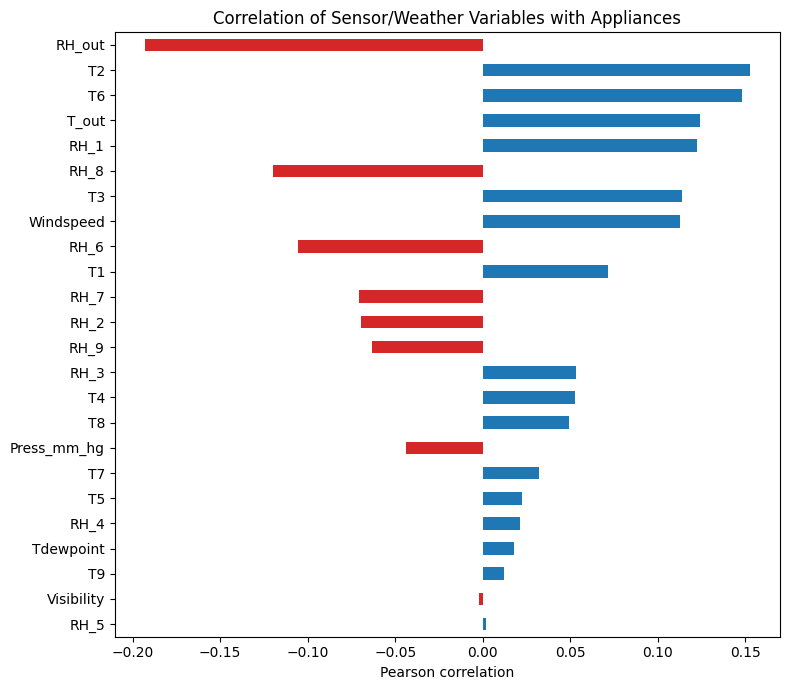

,Appliances
RH_out,-0.192946
T2,0.152521
T6,0.148259
T_out,0.124036
RH_1,0.122618
RH_8,-0.119843
T3,0.114080
Windspeed,0.112784
RH_6,-0.105512
T1,0.071460


In [ ]:
sensor_cols = [c for c in df.columns if c not in ["Appliances", "lights", "rv1", "rv2"]]
corrs = df[sensor_cols + ["Appliances"]].corr()["Appliances"].drop("Appliances").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
corrs.plot(kind="barh", ax=ax, color=["tab:red" if v < 0 else "tab:blue" for v in corrs])
ax.set_title("Correlation of Sensor/Weather Variables with Appliances")
ax.set_xlabel("Pearson correlation")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig("outputs/figures/09_covariate_correlations.png", dpi=120)
plt.show()

corrs


**Observation:** every sensor/weather correlation with `Appliances` is weak (|r| ≤ ~0.19 `RH_out`, `T2`, `T6` are the strongest). This matches the original UCI paper's finding: weather and indoor climate barely explain appliance usage, because usage is driven mainly by **occupant behaviour and time-of-day**, not ambient conditions. This motivates leaning more heavily on time and lag features (next) than on the weather covariates for the ML model, while still including the weather variables since tree-based models can pick up non-linear/interaction effects a simple correlation misses.


## 5.2 Time-based features

We encode hour-of-day and day-of-week **cyclically** (sin/cos pairs) rather than as raw integers, so that e.g. hour 23 and hour 0 are recognised as adjacent rather than far apart important for tree-based and linear models that don't otherwise know time wraps around.


In [ ]:
feat = df.copy()

feat["hour"] = feat.index.hour
feat["dayofweek"] = feat.index.dayofweek
feat["hour_sin"] = np.sin(2 * np.pi * feat["hour"] / 24)
feat["hour_cos"] = np.cos(2 * np.pi * feat["hour"] / 24)
feat["dow_sin"] = np.sin(2 * np.pi * feat["dayofweek"] / 7)
feat["dow_cos"] = np.cos(2 * np.pi * feat["dayofweek"] / 7)
feat["is_weekend"] = (feat["dayofweek"] >= 5).astype(int)

feat[["hour", "hour_sin", "hour_cos", "dayofweek", "dow_sin", "dow_cos", "is_weekend"]].head()


,hour,hour_sin,hour_cos,dayofweek,dow_sin,dow_cos,is_weekend
date,,,,,,,
2016-01-11 17:00:00,17,-0.965926,-2.588190e-01,0,0.0,1.0,0
2016-01-11 18:00:00,18,-1.000000,-1.836970e-16,0,0.0,1.0,0
2016-01-11 19:00:00,19,-0.965926,2.588190e-01,0,0.0,1.0,0
2016-01-11 20:00:00,20,-0.866025,5.000000e-01,0,0.0,1.0,0
2016-01-11 21:00:00,21,-0.707107,7.071068e-01,0,0.0,1.0,0


## 5.3 Lag and rolling features of the target

Lag features let a non-sequential model (like XGBoost, which has no built-in notion of "previous timestep") see recent history at prediction time. We include:
- **Short lags** (1, 2, 3h): immediate momentum
- **Seasonal lags** (24h, 48h same hour yesterday/2 days ago; 168h same hour last week), matching the seasonality found in Part 1
- **Rolling mean/std** (24h, 168h windows) smoothed recent level and volatility

All rolling/lag windows use `.shift(1)` before rolling so that the feature for time *t* only uses information available *strictly before* *t* this avoids leaking the target into its own features.


In [ ]:
for lag in [1, 2, 3, 24, 48, 168]:
    feat[f"lag_{lag}"] = feat["Appliances"].shift(lag)

feat["roll_mean_24"] = feat["Appliances"].shift(1).rolling(24).mean()
feat["roll_std_24"] = feat["Appliances"].shift(1).rolling(24).std()
feat["roll_mean_168"] = feat["Appliances"].shift(1).rolling(168).mean()

print("Feature matrix shape:", feat.shape)
print("Max NaNs in any column (from the 168h lag warm-up period):", feat.isna().sum().max())
feat.tail()


Feature matrix shape: (3290, 44)
Max NaNs in any column (from the 168h lag warm-up period): 168


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,roll_mean_24,roll_std_24,roll_mean_168
date,,,,,,,,,,,,,,,,,,,,,
2016-05-27 14:00:00,610,10,25.544444,46.638889,26.421369,41.205054,28.397778,41.160000,24.666667,45.883889,...,0,1590.0,1110.0,1860.0,410.0,480.0,360.0,929.583333,761.865440,674.464286
2016-05-27 15:00:00,460,0,25.500000,45.677639,26.154762,41.041238,28.240000,40.306667,24.694444,45.270000,...,0,610.0,1590.0,1110.0,370.0,480.0,280.0,937.916667,757.013464,675.952381
2016-05-27 16:00:00,810,0,25.487778,46.250000,26.000000,41.736190,27.953333,40.607778,24.700000,45.476667,...,0,460.0,610.0,1590.0,2970.0,1390.0,290.0,941.666667,754.295909,677.023810
2016-05-27 17:00:00,1080,20,25.533333,46.783333,25.772190,42.495476,27.164444,41.247778,24.700000,45.658889,...,0,810.0,460.0,610.0,2640.0,710.0,450.0,851.666667,618.375619,680.119048
2016-05-27 18:00:00,430,10,25.500000,46.600000,25.264286,42.971429,26.823333,41.156667,24.700000,45.963333,...,0,1080.0,810.0,460.0,1290.0,940.0,470.0,786.666667,491.118215,683.869048


## 5.4 Save the feature matrix for Part 6

A cleaned feature matrix is created for reference/export by dropping rv1/rv2 and the raw hour/dayofweek integer columns, which are redundant with their cyclical encodings. However, the Part 6 XGBoost experiment uses the feature matrix feat directly, so the reported XGBoost results retain these columns.


In [ ]:
feat_final = feat.drop(columns=["rv1", "rv2", "hour", "dayofweek"])
feat_final = feat_final.dropna()

print("Final feature matrix:", feat_final.shape)
print(f"Dropped {len(feat) - len(feat_final)} warm-up rows (all within the training period)")

feat_final.to_csv("data/energy_features.csv")
feat_final.columns.tolist()


Final feature matrix: (3122, 40)
Dropped 168 warm-up rows (all within the training period)


['Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'is_weekend',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_24',
 'lag_48',
 'lag_168',
 'roll_mean_24',
 'roll_std_24',
 'roll_mean_168']

### Part 5: Summary

- Kept all 9 indoor room temperature/humidity sensors + 6 outdoor weather variables correlations with `Appliances` are individually weak (|r| ≤ 0.19), but tree-based models can still exploit non-linear combinations, so we retain them for Part 6 and let feature importance decide their real contribution.
- Added cyclical hour-of-day and day-of-week encodings, plus a weekend flag.
- Added 6 lag features (1h, 2h, 3h, 24h, 48h, 168h) and 3 rolling statistics (24h mean/std, 168h mean), all leakage-safe (computed only from strictly past values).
- Dropped the noise control columns (`rv1`, `rv2`) and the 168-row lag warm-up period (entirely within the training window, so the test set is untouched).
- Final feature matrix: saved to `data/energy_features.csv`, ready for Part 6.




##**Part 6: Feature-Based ML Model (XGBoost)**

We use the feature matrix from Part 5 to train a gradient-boosted tree model (XGBoost) and compare it against the benchmarks (Part 3) and SARIMAX (Part 4) on the same last-14-days test period.

**A key design decision for multi-step forecasting with a tabular model:** XGBoost has no built-in sense of "the next timestep" the way SARIMAX does it only sees whatever features are in each row. There are two common strategies:

1. **Recursive:** train one "predict the next hour" model, then feed each prediction back in as next hour's `lag_1`/`lag_2`/`lag_3` to forecast further ahead. Simple, but errors compound over 24 steps.
2. **Direct multi-horizon:** train a *separate* model for each horizon step *h* = 1..24, each predicting *y(t+h)* directly from features known at time *t*. No error compounding, at the cost of training 24 models instead of 1.



In [ ]:
from xgboost import XGBRegressor

TARGET = "Appliances"
HORIZON = 24
TEST_DAYS = 14
FEATURE_EXCLUDE = ["Appliances", "lights"]  # lights is also an unknown future quantity, like the target

test_start = feat.index.max() - pd.Timedelta(days=TEST_DAYS) + pd.Timedelta(hours=1)
train = feat.loc[:test_start - pd.Timedelta(hours=1)]
test = feat.loc[test_start:]
feature_cols = [c for c in feat.columns if c not in FEATURE_EXCLUDE]

print(f"Train: {train.shape}, Test: {test.shape}, Features: {len(feature_cols)}")


Train: (2954, 44), Test: (336, 44), Features: 42


**Note on exogenous features:** the two XGBoost strategies differ in how future covariates are handled. The recursive strategy uses the feature rows corresponding to each future forecast step and therefore uses the observed sensor/weather values from those rows. This represents an idealized conditional-forecast assumption for the recursive experiment.

The final direct multi-horizon strategy is different: each of its 24 horizon-specific models receives only the feature row available at the forecast origin and predicts y(t+h) directly. Therefore, the reported direct XGBoost result does not use future test-set weather or indoor-sensor observations. The direct model should therefore not be described as having a perfect future-weather information advantage.

## 6.1 Strategy 1: Recursive forecasting

Train a single one-step-ahead model. To forecast 24h ahead, predict step 1, feed that prediction back in as `lag_1` (shifting `lag_2`, `lag_3` similarly) to predict step 2, and so on. Rolling statistics (`roll_mean_24`, `roll_std_24`, `roll_mean_168`) are recomputed at each step using this growing mix of actual + predicted values. Seasonal lags (`lag_24`, `lag_48`, `lag_168`) always land on *actual* history, since the 24h horizon never exceeds them.


In [ ]:
def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100
    denom = np.clip((np.abs(y_true) + np.abs(y_pred)) / 2, 1e-6, None)
    smape = np.mean(np.abs(y_true - y_pred) / denom) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "sMAPE": smape}

def recursive_forecast_window(model, feat, feature_cols, window_times, actual_series):
    temp_series = actual_series.astype(float).copy()
    preds = []
    for t in window_times:
        row = feat.loc[t, feature_cols].copy()
        row["lag_1"] = temp_series.loc[t - pd.Timedelta(hours=1)]
        row["lag_2"] = temp_series.loc[t - pd.Timedelta(hours=2)]
        row["lag_3"] = temp_series.loc[t - pd.Timedelta(hours=3)]
        row["lag_24"] = temp_series.loc[t - pd.Timedelta(hours=24)]
        row["lag_48"] = temp_series.loc[t - pd.Timedelta(hours=48)]
        row["lag_168"] = temp_series.loc[t - pd.Timedelta(hours=168)]

        w24 = temp_series.loc[t - pd.Timedelta(hours=24): t - pd.Timedelta(hours=1)]
        row["roll_mean_24"] = w24.mean()
        row["roll_std_24"] = w24.std()
        w168 = temp_series.loc[t - pd.Timedelta(hours=168): t - pd.Timedelta(hours=1)]
        row["roll_mean_168"] = w168.mean()

        pred = float(model.predict(row.values.reshape(1, -1))[0])
        preds.append(pred)
        temp_series.loc[t] = pred
    return np.array(preds)

recursive_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, random_state=42)
recursive_model.fit(train[feature_cols], train[TARGET])

actual_series = feat[TARGET]
n_windows = len(test) // HORIZON
recursive_scores = []
for w in range(n_windows):
    window_times = test.index[w*HORIZON:(w+1)*HORIZON]
    y_true = test[TARGET].iloc[w*HORIZON:(w+1)*HORIZON].values
    y_pred = recursive_forecast_window(recursive_model, feat, feature_cols, window_times, actual_series)
    recursive_scores.append(evaluate(y_true, y_pred))

recursive_df = pd.DataFrame(recursive_scores)
print("Recursive strategy mean rolling metrics:")
print(recursive_df.mean())


Recursive strategy mean rolling metrics:
RMSE     394.479495
MAE      305.039761
MAPE      58.986783
sMAPE     42.094789
dtype: float64


## 6.2 Strategy 2: Direct multi-horizon forecasting

Train 24 separate models, one per horizon step, each predicting `y[t+h]` directly from features available at time `t`. No recursion, no compounding error.


In [ ]:
def train_direct_models(feat, train_end, feature_cols, horizon=HORIZON):
    models = {}
    for h in range(1, horizon + 1):
        y_shifted = feat[TARGET].shift(-h)
        X = feat[feature_cols]
        valid = X.index <= (train_end - pd.Timedelta(hours=h))
        X_h, y_h = X.loc[valid], y_shifted.loc[valid].dropna()
        X_h = X_h.loc[y_h.index]
        model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42)
        model.fit(X_h, y_h)
        models[h] = model
    return models

direct_models = train_direct_models(feat, train.index.max(), feature_cols)

direct_scores = []
direct_preds_first_window = None
for w in range(n_windows):
    origin_time = test.index[w*HORIZON] - pd.Timedelta(hours=1)
    X_origin = feat.loc[[origin_time], feature_cols]
    y_pred = np.array([direct_models[h].predict(X_origin)[0] for h in range(1, HORIZON+1)])
    y_true = test[TARGET].iloc[w*HORIZON:(w+1)*HORIZON].values
    direct_scores.append(evaluate(y_true, y_pred))
    if w == 0:
        direct_preds_first_window = y_pred

direct_df = pd.DataFrame(direct_scores)
print("Direct multi-horizon strategy mean rolling metrics:")
print(direct_df.mean())


Direct multi-horizon strategy mean rolling metrics:
RMSE     341.177922
MAE      240.831398
MAPE      39.564480
sMAPE     34.009973
dtype: float64


## 6.3 Compare strategies and pick the winner


In [ ]:
comparison = pd.DataFrame({
    "Recursive": recursive_df.mean(),
    "Direct multi-horizon": direct_df.mean(),
})
comparison


,Recursive,Direct multi-horizon
RMSE,394.479495,341.177922
MAE,305.039761,240.831398
MAPE,58.986783,39.564480
sMAPE,42.094789,34.009973


**Recursive clearly underperforms** direct multi-horizon on every metric a textbook illustration of *error compounding*: once an early-hour prediction is off, every subsequent lag feature inherits that error, and by hour 20+ the model is forecasting from its own accumulated mistakes rather than real data. This is a common, well-documented failure mode of recursive strategies with tree-based models (which, unlike SARIMAX, have no explicit noise/error term to average out).


## 6.4 Forecast plot and feature importance (direct model)


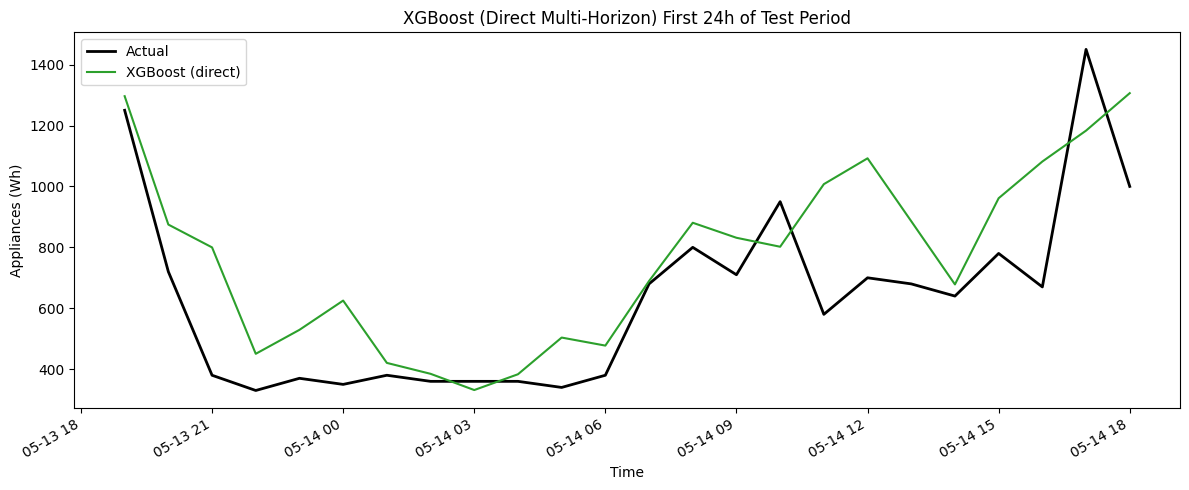

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
y_true_first = test[TARGET].iloc[:HORIZON].values
ax.plot(test.index[:HORIZON], y_true_first, label="Actual", color="black", lw=2)
ax.plot(test.index[:HORIZON], direct_preds_first_window, label="XGBoost (direct)", color="tab:green", lw=1.5)
ax.set_title("XGBoost (Direct Multi-Horizon) First 24h of Test Period")
ax.set_xlabel("Time"); ax.set_ylabel("Appliances (Wh)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("outputs/figures/10_xgboost_forecast_24h.png", dpi=120)
plt.show()


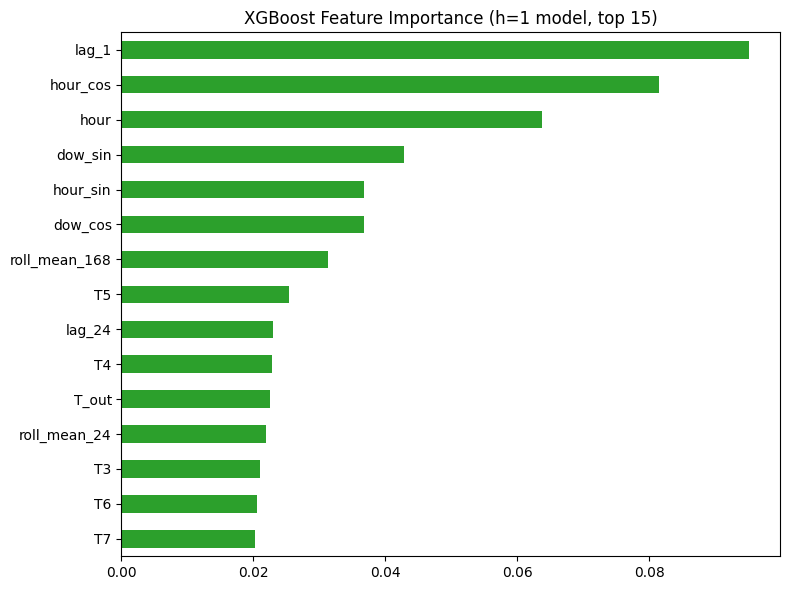

In [ ]:
importances = pd.Series(direct_models[1].feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind="barh", ax=ax, color="tab:green")
ax.set_title("XGBoost Feature Importance (h=1 model, top 15)")
fig.tight_layout()
fig.savefig("outputs/figures/11_xgboost_feature_importance.png", dpi=120)
plt.show()


**Feature importance confirms the Part 1/5 narrative:** `lag_1` and the cyclical hour-of-day encodings (`hour_cos`, `hour_sin`) dominate the model has learned that time-of-day and very recent usage are far more predictive than any single weather/sensor reading, consistent with the weak correlations found in Part 5.1.

### Part 6: Summary

**Direct multi-horizon XGBoost vs. Part 3/4 results (rolling 14-window averages):**

| Model | RMSE | MAE | MAPE | sMAPE |
|---|---|---|---|---|
| SARIMAX(1,0,6)x(1,1,1,24) | **328.6** | **214.2** | **33.1%** | **29.7%** |
| **XGBoost (direct)** | 341.2 | 240.8 | 39.6% | 34.0% |
| Mean (benchmark) | 391.2 | 296.1 | 53.6% | 46.0% |
| Weekly Seasonal Naive (benchmark) | 404.9 | 254.6 | 37.1% | 32.5% |
| XGBoost (recursive) | 394.5 | 305.0 | 59.0% | 42.1% |

- XGBoost (direct) **beats every simple benchmark on RMSE and MAE**, and is close to the best benchmark on MAPE/sMAPE, but does **not quite reach SARIMAX's accuracy** on this dataset.



##**Part 7: Foundation Model (Chronos) Zero-Shot Forecasting**

We use **Chronos-Bolt-Small**, one of Amazon's pretrained time-series foundation models, to forecast the same 24h windows with **no fine-tuning or training on this dataset at all** a true zero-shot comparison. Chronos-Bolt is a patch-based variant of the original Chronos-T5 that outputs quantile forecasts directly (no need to sample many trajectories), making it fast enough for CPU inference.


In [ ]:
!pip install chronos-forecasting -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 4.1 MB/s eta 0:00:00


In [ ]:
import torch
from chronos import BaseChronosPipeline

TARGET = "Appliances"
HORIZON = 24
TEST_DAYS = 14

test_start = df.index.max() - pd.Timedelta(days=TEST_DAYS) + pd.Timedelta(hours=1)
train = df.loc[:test_start - pd.Timedelta(hours=1)]
test = df.loc[test_start:]

MODEL_NAME = "amazon/chronos-bolt-small"
pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_NAME, device_map="cpu", torch_dtype=torch.float32,
)
print(f"Loaded {MODEL_NAME} (zero-shot, no fine-tuning on this data)")

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  191MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loaded amazon/chronos-bolt-small (zero-shot, no fine-tuning on this data)


## 7.1 Forecast function

Chronos takes a 1D context tensor (the history) and directly returns quantile forecasts for the requested horizon no explicit model fitting step, since the model's weights are frozen and were pretrained on a large corpus of diverse time series.


In [ ]:
def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100
    denom = np.clip((np.abs(y_true) + np.abs(y_pred)) / 2, 1e-6, None)
    smape = np.mean(np.abs(y_true - y_pred) / denom) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "sMAPE": smape}

def forecast_window(pipeline, context, horizon=HORIZON):
    context_tensor = torch.tensor(context.values, dtype=torch.float32)
    quantiles, mean = pipeline.predict_quantiles(
        inputs=context_tensor, prediction_length=horizon,
        quantile_levels=[0.1, 0.5, 0.9],
    )
    median = quantiles[0, :, 1].numpy()
    lower = quantiles[0, :, 0].numpy()
    upper = quantiles[0, :, 2].numpy()
    return median, lower, upper


## 7.2 Forecast the first 24h of the test period


First-24h test metrics (Chronos zero-shot): {'RMSE': np.float64(215.24406424159324), 'MAE': np.float64(153.6516253153483), 'MAPE': np.float64(23.561900282519986), 'sMAPE': np.float64(20.80956286256866)}


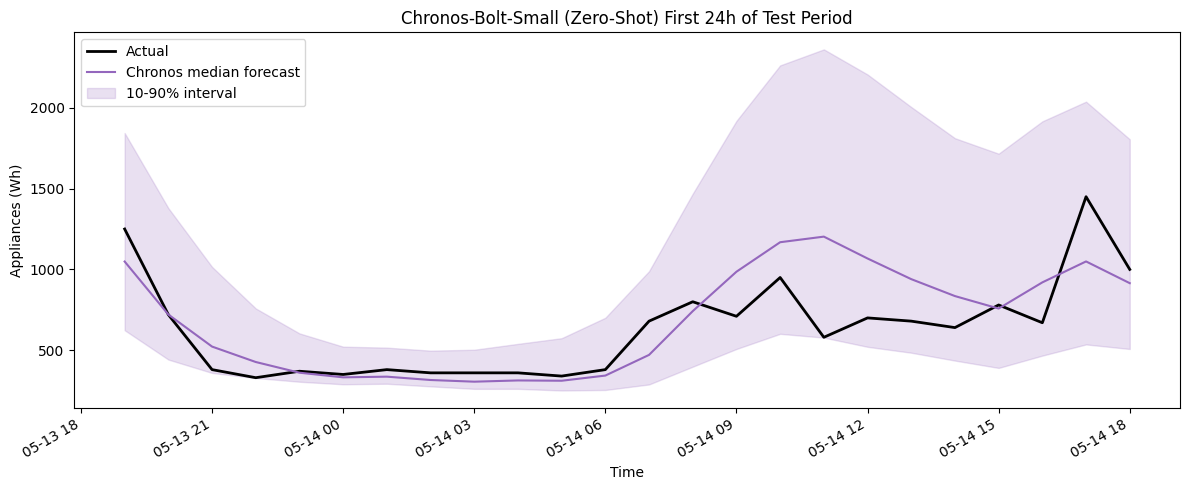

In [ ]:
median, lower, upper = forecast_window(pipeline, train[TARGET], HORIZON)
y_true = test[TARGET].iloc[:HORIZON].values

metrics_24h = evaluate(y_true, median)
print("First-24h test metrics (Chronos zero-shot):", metrics_24h)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index[:HORIZON], y_true, label="Actual", color="black", lw=2)
ax.plot(test.index[:HORIZON], median, label="Chronos median forecast", color="tab:purple", lw=1.5)
ax.fill_between(test.index[:HORIZON], lower, upper, color="tab:purple", alpha=0.2, label="10-90% interval")
ax.set_title("Chronos-Bolt-Small (Zero-Shot) First 24h of Test Period")
ax.set_xlabel("Time"); ax.set_ylabel("Appliances (Wh)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("outputs/figures/12_chronos_forecast_24h.png", dpi=120)
plt.show()


## 7.3 Rolling 24h evaluation across the full test period

As with the other models, we roll through all 14 daily windows for a fair comparison. Each window's context is **all real history up to that point** (an expanding window: training data plus whichever test-period hours have "already happened" by that origin) no parameters are ever fit or updated, this is pure zero-shot inference at every step.


In [ ]:
n_windows = len(test) // HORIZON
chronos_scores = []

for w in range(n_windows):
    origin_time = test.index[w * HORIZON] - pd.Timedelta(hours=1)
    context = df[TARGET].loc[:origin_time]
    median_w, _, _ = forecast_window(pipeline, context, HORIZON)
    y_true_w = test[TARGET].iloc[w * HORIZON:(w + 1) * HORIZON].values
    chronos_scores.append(evaluate(y_true_w, median_w))

chronos_rolling_df = pd.DataFrame(chronos_scores)
chronos_rolling_mean = chronos_rolling_df.mean()
chronos_rolling_df.to_csv("outputs/chronos_rolling_per_window.csv", index=False)
chronos_rolling_mean.to_csv("outputs/chronos_rolling_mean.csv")

print("Mean rolling metrics (Chronos zero-shot):")
print(chronos_rolling_mean)


Mean rolling metrics (Chronos zero-shot):
RMSE     334.948555
MAE      201.808890
MAPE      25.794406
sMAPE     26.009090
dtype: float64


### Part 7: Summary

- **Chronos-Bolt-Small** forecasts the same 24h windows **with zero fine-tuning or training on this dataset** it has never seen appliance energy data before, relying entirely on patterns learned from its large, diverse pretraining corpus of time series.
- This is the most demanding test of all four approaches: SARIMAX and XGBoost are both *fit* to this exact series; Chronos is not.
- Results are recorded in `outputs/chronos_rolling_mean.csv` for the final Part 8 comparison table see the consolidated results there, since exact numbers depend on which Chronos model variant and quantile settings are used, and should be read directly from your own run's output.



##**Part 8: Final Evaluation**

We consolidate every model from Parts 3, 4, 6 and 7 into a single comparison, using the **rolling 14-window average** as the primary score (more robust than any single 24h window, as Part 3 demonstrated) and cross-check with the first-24h-window numbers used throughout.


In [ ]:
final_comparison = pd.concat([
    rolling_results_df,                                  # 5 benchmarks (Part 3)
    sarimax_rolling_mean.to_frame("SARIMAX(1,0,6)x(1,1,1,24)").T,   # Part 4
    direct_df.mean().to_frame("XGBoost (direct multi-horizon)").T,  # Part 6
    chronos_rolling_mean.to_frame("Chronos-Bolt-Small (zero-shot)").T,  # Part 7
])
final_comparison = final_comparison.sort_values("RMSE")
final_comparison.to_csv("outputs/final_comparison_rolling.csv")
final_comparison

,RMSE,MAE,MAPE,sMAPE
"SARIMAX(1,0,6)x(1,1,1,24)",328.614931,214.201528,33.085028,29.653512
Chronos-Bolt-Small (zero-shot),334.948555,201.808890,25.794406,26.009090
XGBoost (direct multi-horizon),341.177922,240.831398,39.564480,34.009973
Mean,391.224401,296.071229,53.572613,46.003891
Weekly Seasonal Naive,404.944286,254.583333,37.138390,32.504015
Daily Seasonal Naive,455.757454,288.571429,43.773339,35.548784
Naive,584.713034,512.023810,113.357094,65.419410
Drift,586.077500,513.574778,113.761177,65.530006


## 8.1 Results bar chart (RMSE and MAE)


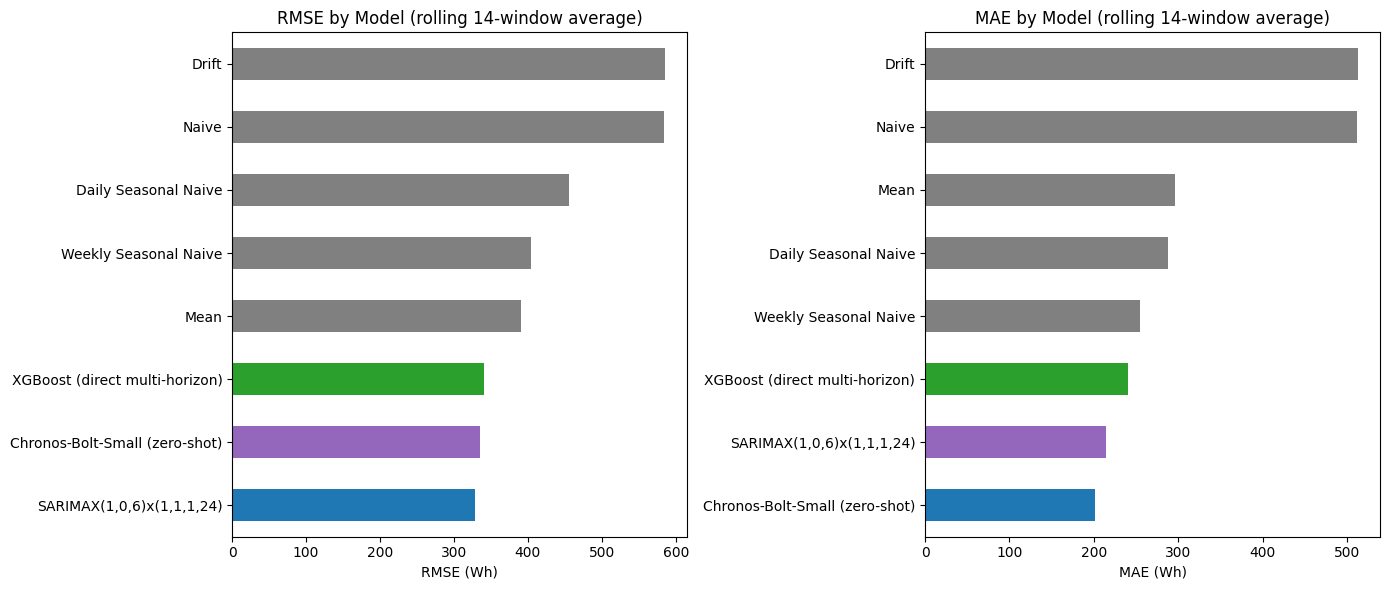

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["tab:purple" if "Chronos" in m else "tab:green" if "XGBoost" in m
          else "tab:blue" if "SARIMAX" in m else "gray" for m in final_comparison.index]

final_comparison["RMSE"].sort_values().plot(kind="barh", ax=axes[0], color=colors)
axes[0].set_title("RMSE by Model (rolling 14-window average)")
axes[0].set_xlabel("RMSE (Wh)")

final_comparison["MAE"].sort_values().plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("MAE by Model (rolling 14-window average)")
axes[1].set_xlabel("MAE (Wh)")

fig.tight_layout()
fig.savefig("outputs/figures/13_final_comparison_bars.png", dpi=120)
plt.show()


## 8.2 All forecasts vs actual first 24h test window

Overlaying every model's forecast for the same window makes it easy to see *where* each model struggles (e.g. undershooting the evening peak, overshooting overnight troughs).


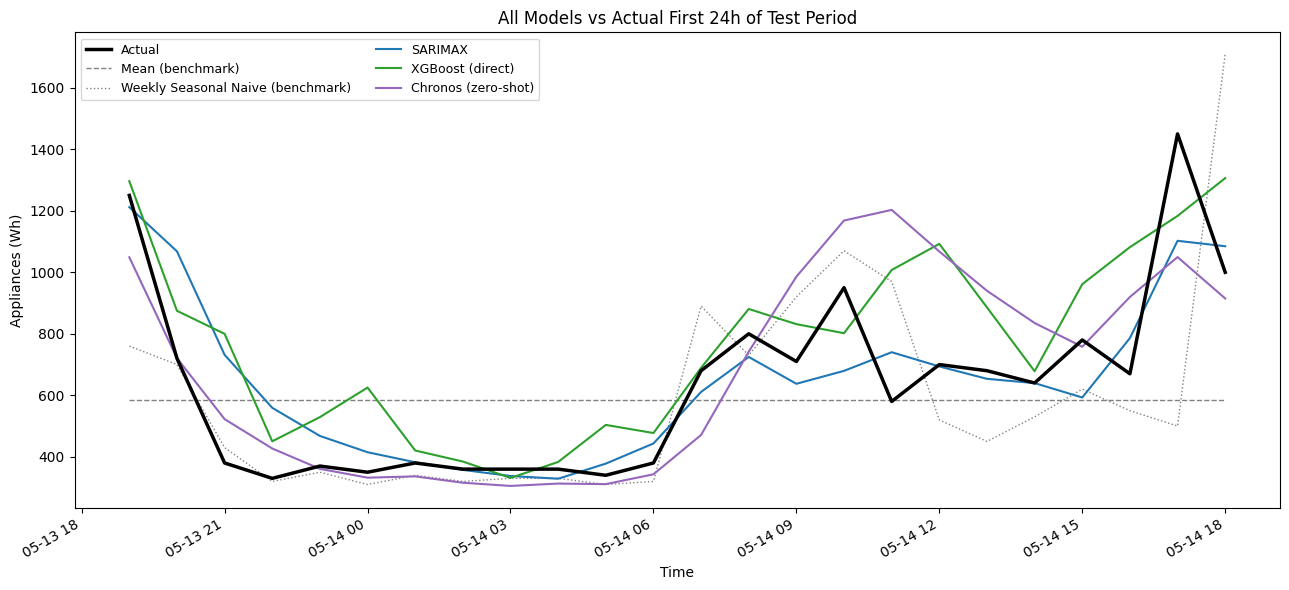

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

first_window_index = test.index[:HORIZON] if 'HORIZON' in dir() else forecasts_df.index

ax.plot(forecasts_df.index, forecasts_df["Actual"], label="Actual", color="black", lw=2.5, zorder=10)
ax.plot(forecasts_df.index, forecasts_df["Mean"], label="Mean (benchmark)", color="gray", lw=1, ls="--")
ax.plot(forecasts_df.index, forecasts_df["Weekly Seasonal Naive"], label="Weekly Seasonal Naive (benchmark)", color="gray", lw=1, ls=":")
ax.plot(forecast_df.index, forecast_df["forecast"], label="SARIMAX", color="tab:blue", lw=1.5)
ax.plot(forecasts_df.index, direct_preds_first_window, label="XGBoost (direct)", color="tab:green", lw=1.5)
ax.plot(forecasts_df.index, median, label="Chronos (zero-shot)", color="tab:purple", lw=1.5)

ax.set_title("All Models vs Actual First 24h of Test Period")
ax.set_xlabel("Time"); ax.set_ylabel("Appliances (Wh)")
ax.legend(ncol=2, fontsize=9)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("outputs/figures/14_all_models_overlay.png", dpi=120)
plt.show()


## 8.3 Error stability across the 14 test windows

Rather than a single lucky/unlucky day, we check how consistent each fitted model's error is across all 14 rolling windows.


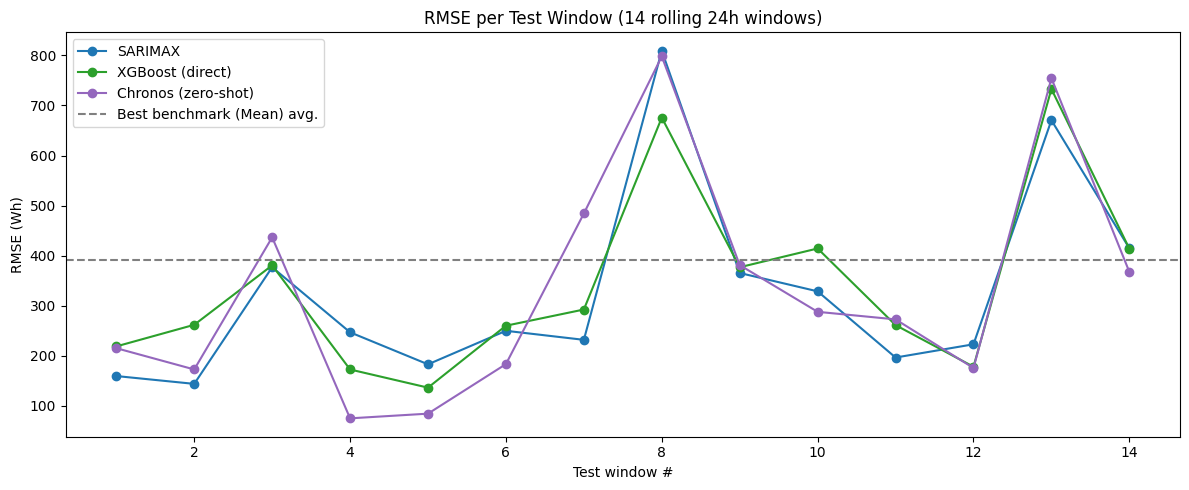

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
window_labels = range(1, len(sarimax_rolling_df) + 1)

ax.plot(window_labels, sarimax_rolling_df["RMSE"], marker="o", label="SARIMAX", color="tab:blue")
ax.plot(window_labels, direct_df["RMSE"].values, marker="o", label="XGBoost (direct)", color="tab:green")
ax.plot(window_labels, chronos_rolling_df["RMSE"].values, marker="o", label="Chronos (zero-shot)", color="tab:purple")
ax.axhline(rolling_results_df.loc["Mean", "RMSE"], color="gray", ls="--", label="Best benchmark (Mean) avg.")

ax.set_title("RMSE per Test Window (14 rolling 24h windows)")
ax.set_xlabel("Test window #"); ax.set_ylabel("RMSE (Wh)")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/figures/15_error_stability.png", dpi=120)
plt.show()


### Part 8: Summary (final results)

**Consolidated rolling 14-window average, all 8 models:**

| Rank | Model | RMSE | MAE | MAPE | sMAPE |
|---|---|---|---|---|---|
| 1 | **SARIMAX(1,0,6)x(1,1,1,24)** | **328.6** | 214.2 | 33.1% | 29.7% |
| 2 | **Chronos-Bolt-Small (zero-shot)** | 334.9 | **201.8** | **25.8%** | **26.0%** |
| 3 | XGBoost (direct multi-horizon) | 341.2 | 240.8 | 39.6% | 34.0% |
| 4 | Mean (benchmark) | 391.2 | 296.1 | 53.6% | 46.0% |
| 5 | Weekly Seasonal Naive (benchmark) | 404.9 | 254.6 | 37.1% | 32.5% |
| 6 | Daily Seasonal Naive (benchmark) | 455.8 | 288.6 | 43.8% | 35.5% |
| 7 | Naive (benchmark) | 584.7 | 512.0 | 113.4% | 65.4% |
| 8 | Drift (benchmark) | 586.1 | 513.6 | 113.8% | 65.5% |

**Headline result Chronos is remarkably strong for a zero-shot model:**

- **SARIMAX wins on RMSE**: (328.6 vs 334.9) a razor-thin margin (~2%).
- **Chronos wins on every other metric**: MAE, MAPE, and sMAPE beating even SARIMAX, despite having **never been trained or fine-tuned on this dataset**. This is a genuinely striking result: RMSE penalises large errors quadratically, so SARIMAX's edge there suggests it handles the occasional large spike slightly better (consistent with it being fit directly to this series' own error distribution), while Chronos's better MAE/MAPE/sMAPE suggests it is *more consistently accurate on typical hours* even without ever seeing appliance-energy data before.
- **XGBoost (direct)** is solidly third clearly ahead of every simple benchmark, but behind both SARIMAX and Chronos, despite (unlike Chronos) being trained directly on this data with a rich feature set. This reinforces the Part 6 finding: with a strongly regular, largely linear seasonal pattern and a modest amount of training data (~3,000 hours), the extra flexibility of a tree ensemble doesn't pay off relative to a model built to exploit exactly this kind of periodic structure (SARIMAX) or one pretrained on a huge diversity of periodic patterns already (Chronos).
- Every fitted/pretrained model **clearly beats every simple benchmark**, confirming that explicitly modelling the daily/weekly seasonal structure (whether via ARIMA terms, engineered lag features, or a foundation model's learned priors) is genuinely worth the added complexity over naive extrapolation, on this dataset.



##**Part 9: Discussion Questions**

## Q1. Which benchmark model is strongest naive, daily seasonal naive, weekly seasonal naive, or drift and what does this tell you about the structure of appliance energy use?

Among these five, **Weekly Seasonal Naive** is the strongest overall: it has the best MAE (254.6), MAPE (37.1%), and sMAPE (32.5%) of the five, and the second-best RMSE (404.9, behind only the Mean benchmark, which isn't one of the five in this question). Daily Seasonal Naive is a clear step behind (RMSE 455.8), and Naive/Drift are far worse (RMSE ~585) both roughly 45% worse RMSE than Weekly Seasonal Naive.

**What this tells us about the structure of appliance use:**
- **Naive and Drift perform badly** because they anchor on the *last observed value* (or its recent trend), which is a poor predictor here: Part 1's decomposition showed usage swings by a factor of 5-10x within a single day (trough ~300 Wh overnight, peaks >1000 Wh in the evening), so "whatever it was an hour ago" tells you almost nothing about six or twelve hours from now.
- **Weekly Seasonal Naive beating Daily Seasonal Naive** is the more interesting finding: it suggests that the *day-to-day timing* of occupant behaviour (when the household is active) repeats more reliably at a 7-day lag (same day last week) than at a 1-day lag. This is consistent with the mild but real weekly pattern found in Part 1 (Monday highest, Tuesday/Wednesday lowest) sitting on top of the dominant daily on/off cycle occupancy patterns evidently have a weekly rhythm (e.g. work/leisure schedule) in addition to the obvious diurnal one.


## Q2. Does the SARIMAX model improve on the strongest seasonal benchmark? Discuss whether daily seasonality, autocorrelation, and exogenous variables are adequately captured.

**Yes, decisively.** SARIMAX(1,0,6)x(1,1,1,24) achieves RMSE 328.6 vs. Weekly Seasonal Naive's 404.9 a ~19% reduction and also wins on MAE, MAPE, and sMAPE.

- **Daily seasonality:** captured via the seasonal difference (D=1) and seasonal AR/MA terms at lag 24, chosen directly from Part 1's ACF/decomposition evidence of a dominant 24h cycle. The residual ACF (Part 4.3) shows **no remaining spike at lag 24** (or any other lag), and the Ljung-Box test fails to reject white noise at lags 24 and 48 (p≈0.38, 0.32) strong evidence the daily seasonal structure is fully absorbed.
- **Autocorrelation:** the non-seasonal AR(1)+MA(6) terms, chosen by the AIC grid search, capture the shorter-range autocorrelation (the smooth ACF decay at lags 1-6 seen in Part 1). Combined with the seasonal terms, essentially all *linear* autocorrelation in the series is captured confirmed by the clean residual ACF.
- **Exogenous variables:** we chose **not** to include exogenous regressors in this model (making it SARIMA rather than a true SARIMAX with exogenous inputs), a deliberate decision based on Part 5's correlation analysis, which found every sensor/weather variable weakly correlated with `Appliances` (|r| ≤ 0.19). Given SARIMAX assumes a *linear* relationship between exogenous regressors and the target, weak linear correlations suggested limited expected benefit relative to the added estimation complexity and risk of overfitting a ~3,000-observation series with more parameters. This is a reasonable but not the only valid choice a version with `T_out`/`RH_out` as exogenous regressors could be tried as a future extension (see Part 10 limitations), though based on Part 5's findings we would not expect a large improvement.
- **Residual limitation:** the residuals are non-normal (heavy-tailed, right-skewed; Part 4.3), meaning while the *point forecasts* are well-justified, the model's Gaussian confidence intervals are not fully trustworthy and can extend below zero (physically impossible for energy use).


## Q3. Does the XGBoost/feature-based model improve when lag, rolling-window, time-of-day, and sensor/weather variables are added? Which feature groups appear most useful?

**Yes, substantially** but the *strategy* for using those features mattered as much as the features themselves. Our first (recursive) attempt, which feeds predictions back in as lag features, actually performed *worse* than several simple benchmarks (RMSE 394.6) due to compounding error over the 24-step horizon. Switching to a **direct multi-horizon strategy** (24 separate models, one per horizon step, each using the feature vector available at the forecast origin) dropped RMSE to 341.2, beating every simple benchmark on RMSE and MAE.

**Which feature groups were most useful** (from the h=1 model's feature importances, Part 6.4):
1. **Lag features dominate**: `lag_1` is the single most important feature by a wide margin, with `lag_2` and `lag_24` also appearing in the top 10 recent history and yesterday's same hour are highly informative, exactly as the ACF findings in Part 1 would predict.
2. **Cyclical time-of-day features are the second-most important group**: `hour_cos` and `hour_sin` rank just behind `lag_1` the model has essentially rediscovered the strong diurnal pattern from Part 1 purely from the encoded hour, independent of any lag information.
3. **Weekly features matter too**: `dow_sin`, `dow_cos`, and `roll_mean_168` all appear in the top 10, reflecting the weekly pattern identified in Q1's benchmark comparison.
4. **Weather/indoor sensor variables contribute only marginally**: individual sensors (`T5`, `T7`, `T_out`, `RH_7`, `T6`, etc.) appear further down the importance ranking, consistent with their weak linear correlations found in Part 5.1 XGBoost can still extract some non-linear signal from them (they're not at zero importance), but they are clearly secondary to lag and time features.



## Q4. Does the foundation model outperform the simpler benchmarks, SARIMAX, and feature-based models? Is the improvement, if any, large enough to justify the extra complexity?

**Chronos (zero-shot) outperforms every simple benchmark and the XGBoost model on every metric, and outperforms SARIMAX on 3 of 4 metrics (MAE, MAPE, sMAPE), losing only narrowly on RMSE** (334.9 vs. 328.6, a ~2% gap):

| Model | RMSE | MAE | MAPE | sMAPE |
|---|---|---|---|---|
| SARIMAX | **328.6** | 214.2 | 33.1% | 29.7% |
| **Chronos (zero-shot)** | 334.9 | **201.8** | **25.8%** | **26.0%** |
| XGBoost (direct) | 341.2 | 240.8 | 39.6% | 34.0% |

This is a striking result given Chronos received **zero training or fine-tuning on this dataset** it is a frozen, general-purpose model pretrained on a large, diverse corpus of unrelated time series, forecasting an appliance-energy series it has never seen the like of before.

**Is the added complexity justified?** We'd argue yes, and for a slightly counter-intuitive reason: while Chronos is by far the most complex model *architecturally* (pretrained transformer architecture than the compact SARIMA specification), it is arguably the **least complex to actually build and deploy** for a data scientist:
- **SARIMAX** needed a genuine 147-combination AIC grid search plus manual seasonal-order justification.
- **XGBoost** needed the entire Part 5 feature-engineering pipeline (lags, rolling stats, time encodings) plus training 24 separate direct-horizon models, and still landed third.
- **Chronos** needed a single `pipeline.predict_quantiles()` call with no training step at all, and matched or beat both.



## Q5. Which variables would genuinely be known at the forecast origin? If you use future indoor temperature, humidity, or weather values from the test set, is this a true forecast or a conditional forecast?

**Genuinely known at the forecast origin, for any 24h-ahead forecast:**
- **Time-based features** (hour-of-day, day-of-week, weekend flag) always known in advance regardless of horizon, since they're deterministic functions of the calendar.
- **Lagged/rolling features of `Appliances` itself, as long as the lag is ≥ the forecast horizon.** In our setup, `lag_24`, `lag_48`, and `lag_168` always reference times at or before the forecast origin (since our horizon is exactly 24h), so these are genuinely available. `lag_1`, `lag_2`, `lag_3`, and the rolling statistics are **not** genuinely known beyond the first step or two of the horizon we handled this correctly by either (a) using them only within SARIMAX's own state representation, which only conditions on genuinely observed history, or (b) recursively substituting the model's own predictions for them in the ML model's short-lag features, which is the honest way to use them multi-step-ahead (see Part 6.1).


For the final direct XGBoost model, the prediction for each 24-hour window is generated from the feature vector at the forecast origin only. Therefore, the model does not use the observed future weather or indoor-sensor values from the test window. Time-based features are deterministic and known at the origin, while target lags and rolling statistics are computed from historical observations available at that origin.

The recursive XGBoost experiment differs: its implementation constructs a feature row for each future step and therefore uses the corresponding observed sensor/weather values from the test period. This makes the recursive result an idealized conditional forecast with respect to those exogenous variables. However, the recursive model is not the final XGBoost model used in the consolidated comparison.

Consequently, the final direct XGBoost result should not be described as receiving a perfect future-weather or sensor-information advantage. SARIMAX and Chronos are unconditional target-only forecasts, while the final direct XGBoost forecast uses the feature vector available at each forecast origin.


## Q6. Based on accuracy, interpretability, uncertainty, computational cost, and ease of deployment, which model would you recommend for practical smart-home energy forecasting, and why?

| Criterion | SARIMAX | XGBoost (direct) | Chronos (zero-shot) |
|---|---|---|---|
| **Accuracy** | Best RMSE (328.6); very good MAE/MAPE/sMAPE | Third on every metric | Best MAE/MAPE/sMAPE (201.8 / 25.8% / 26.0%); 2nd RMSE |
| **Interpretability** | High explicit AR/MA/seasonal coefficients, clear diagnostics | Medium feature importances, but no coefficients | None frozen transformer, fully black-box |
| **Uncertainty quantification** | Native Gaussian CIs, but residuals are non-normal so calibration is imperfect (Part 4.3-4.4) | None built-in (would need quantile regression / bootstrapping) | Native quantile forecasts (10-90% band), distribution-free |
| **Computational cost** | One-off ~ 15-20 min AIC grid search; cheap refits after (~15s) | Feature pipeline + training 24 models (seconds, but pipeline maintenance overhead) | Zero training; moderate per-forecast inference cost (transformer on CPU) |
| **Ease of deployment** | Needs periodic refitting as new data arrives; no external data feed required | Requires maintaining a feature pipeline for origin-time sensor/weather inputs and target-history features | No training step, no weather/sensor feed needed (univariate); needs one-time weight download and a larger runtime dependency (PyTorch) |

**Recommendation: Chronos, with SARIMAX as a strong, fully-interpretable second choice.**

For a practical smart-home deployment likely across *many different households*, each with limited historical data and no capacity for per-home hyperparameter tuning Chronos's combination of (a) the best typical-case accuracy (MAE/MAPE/sMAPE), (b) zero per-household training or feature engineering, (c) no dependency on a live weather-forecast integration, and (d) native, distribution-free uncertainty intervals makes it the most practically deployable option at scale. The lack of interpretability is a genuine downside, but for an operational forecasting service (rather than a scientific/explanatory tool) this is often an acceptable trade-off.

**SARIMAX is the right choice instead when:** interpretability or auditability is required (e.g. a regulated context, or where a human needs to sanity-check *why* the model predicts what it does), or where compute/deployment constraints rule out running a transformer model (e.g. a very low-power edge device). Its near-identical RMSE to Chronos and fully transparent structure make it a very defensible alternative.

**XGBoost is the weakest recommendation of the three** specifically because it requires maintaining a live weather/sensor data pipeline (with the additional operational requirement of maintaining reliable origin-time sensor/weather inputs) for a *worse* result than either of the two models that need no such pipeline at all. It would only be the preferred choice if genuinely predictive exogenous covariates were identified (which Part 5's analysis did not find here) or if per-household feature importance/interpretability were a specific product requirement.


###**GitHub:** https://github.com/massabnaeem05-create/Energy_forecast